# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**
*Edición 2023*

----

## **Aprendizaje Supervisado**
## **Kaggle Competition**

**GRUPO 11**
- Mendoza, Ruben Alfredo
- Risso, Sofia Agostina


**CONSIGNA**

Presentamos un código creado como ejemplo de base para la competición.

Deben:

- Explorar los datos y aprender de ellos.
- Probar diferentes modelos y ver cuáles ajustan mejor dado los datos.
- **Obtener una accuracy mejor que la que se presenta en este ejemplo.**
- Tratar de obtener la accuracy más alta posible!
- Discutir la elección de modelo.

El análisis exploratorio y el preprocesamiento de los datos queda a libertad de cada grupo y no deben quedarse con este simple ejemplo.

**NOTA: se analizaron los cuatro mejores modelos.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Para el tratamiento de los datos y las metricas
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Los modelos a usar
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from xgboost import XGBClassifier, XGBRFClassifier
from sklearn.neighbors import KNeighborsClassifier

## Lectura del dataset

### Train

Se cargaron los datos de entrenamiento que se utilizaron para generar el modelo.

In [ ]:
df_train = pd.read_csv('diabetes_prediction_dataset_train-labeled.csv')
df_train

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,20432,Male,4.0,0,0,never,19.28,3.5,155,0
1,49682,Female,50.0,0,0,former,27.32,5.7,159,0
2,73886,Female,43.0,0,0,never,21.54,4.5,145,0
3,53144,Male,64.0,0,0,current,28.22,6.0,130,0
4,98507,Male,10.0,0,0,No Info,15.46,6.1,140,0
...,...,...,...,...,...,...,...,...,...,...
94995,81090,Female,56.0,0,0,never,22.30,6.2,158,0
94996,90924,Female,24.0,0,0,never,22.50,6.1,126,0
94997,64600,Female,32.0,0,0,never,24.92,6.6,145,0
94998,96132,Female,21.0,0,0,current,20.59,4.5,155,0


In [ ]:
df_train.describe()

,patient,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000
mean,50016.501389,41.935269,0.075074,0.039463,27.320879,5.527659,138.070537,0.085074
std,28868.357071,22.514788,0.263512,0.194695,6.626335,1.070261,40.739962,0.278993
min,1.000000,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,25021.750000,24.000000,0.000000,0.000000,23.650000,4.800000,100.000000,0.000000
50%,50024.000000,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,75024.250000,60.000000,0.000000,0.000000,29.580000,6.200000,159.000000,0.000000
max,100000.000000,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient              95000 non-null  int64  
 1   gender               95000 non-null  object 
 2   age                  95000 non-null  float64
 3   hypertension         95000 non-null  int64  
 4   heart_disease        95000 non-null  int64  
 5   smoking_history      95000 non-null  object 
 6   bmi                  95000 non-null  float64
 7   HbA1c_level          95000 non-null  float64
 8   blood_glucose_level  95000 non-null  int64  
 9   diabetes             95000 non-null  int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 7.2+ MB


La columna ***`diabetes`*** es la columna que debemos predecir. En el dataset de Test esta columna tiene valores nulos.

### Test

Se cargaron los datos de test. Estos datos son los que utilizaron para predecir si las personas tienen diabetes y generar el archivo `submision.csv` para utilizar en la competencia de Kaggle.

In [ ]:
df_test = pd.read_csv('diabetes_prediction_dataset_test.csv')
df_test

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,49267,Male,53.0,0,0,never,31.99,4.5,126,NaN
1,82280,Female,22.0,0,0,never,25.96,6.6,130,NaN
2,33216,Female,37.0,0,0,never,22.24,6.2,126,NaN
3,94551,Female,29.0,0,0,not current,31.01,5.0,80,NaN
4,43760,Male,30.0,0,0,ever,28.66,6.6,100,NaN
...,...,...,...,...,...,...,...,...,...,...
4995,88540,Female,23.0,0,0,never,22.77,6.6,200,NaN
4996,26701,Female,51.0,0,0,No Info,27.32,4.0,155,NaN
4997,47271,Male,79.0,0,0,No Info,23.80,6.0,126,NaN
4998,97941,Male,24.0,0,0,never,22.68,6.1,85,NaN


In [ ]:
df_test.describe()

,patient,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,0.0
mean,49696.473600,40.947016,0.070600,0.038600,27.318644,5.524620,137.821000,NaN
std,28855.568156,22.537466,0.256181,0.192659,6.832943,1.078559,40.101933,NaN
min,7.000000,0.160000,0.000000,0.000000,10.620000,3.500000,80.000000,NaN
25%,24720.750000,23.000000,0.000000,0.000000,23.410000,4.800000,100.000000,NaN
50%,49522.500000,41.000000,0.000000,0.000000,27.320000,5.800000,140.000000,NaN
75%,74686.000000,59.000000,0.000000,0.000000,29.632500,6.200000,159.000000,NaN
max,99970.000000,80.000000,1.000000,1.000000,88.760000,9.000000,300.000000,NaN


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient              5000 non-null   int64  
 1   gender               5000 non-null   object 
 2   age                  5000 non-null   float64
 3   hypertension         5000 non-null   int64  
 4   heart_disease        5000 non-null   int64  
 5   smoking_history      5000 non-null   object 
 6   bmi                  5000 non-null   float64
 7   HbA1c_level          5000 non-null   float64
 8   blood_glucose_level  5000 non-null   int64  
 9   diabetes             0 non-null      float64
dtypes: float64(4), int64(4), object(2)
memory usage: 390.8+ KB


Se realizaron copias de ambos set de datos para poder hacer un análisis exploratorio sin modificar los data frames originales. En ambas copias, se descartó la columna `patient`, ya que este es un dato puramente administrativo que no influye en el diágnostico.

Se observó que a excepción de la columna `diabetes` del set de datos de prueba, no existían columnas con valores faltantes.

In [ ]:
df_train_copy = df_train.copy().drop('patient', axis=1)
df_train_copy

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Male,4.0,0,0,never,19.28,3.5,155,0
1,Female,50.0,0,0,former,27.32,5.7,159,0
2,Female,43.0,0,0,never,21.54,4.5,145,0
3,Male,64.0,0,0,current,28.22,6.0,130,0
4,Male,10.0,0,0,No Info,15.46,6.1,140,0
...,...,...,...,...,...,...,...,...,...
94995,Female,56.0,0,0,never,22.30,6.2,158,0
94996,Female,24.0,0,0,never,22.50,6.1,126,0
94997,Female,32.0,0,0,never,24.92,6.6,145,0
94998,Female,21.0,0,0,current,20.59,4.5,155,0


In [ ]:
df_test_copy = df_test.copy().drop('patient', axis=1)
df_test_copy

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Male,53.0,0,0,never,31.99,4.5,126,NaN
1,Female,22.0,0,0,never,25.96,6.6,130,NaN
2,Female,37.0,0,0,never,22.24,6.2,126,NaN
3,Female,29.0,0,0,not current,31.01,5.0,80,NaN
4,Male,30.0,0,0,ever,28.66,6.6,100,NaN
...,...,...,...,...,...,...,...,...,...
4995,Female,23.0,0,0,never,22.77,6.6,200,NaN
4996,Female,51.0,0,0,No Info,27.32,4.0,155,NaN
4997,Male,79.0,0,0,No Info,23.80,6.0,126,NaN
4998,Male,24.0,0,0,never,22.68,6.1,85,NaN


Sobre el set de datos de entrenamiento se realizó un `pairplot` para visualizar la relación entre las múltiples variables numéricas, diferenciando con colores diferentes aquellos entre quienes presentan diabetes y los que no. Esto se realizó con el fin de visualizar si existían agrupamientos en las observaciones y al mismo tiempo, analizar si se encontraba alguna correlación.

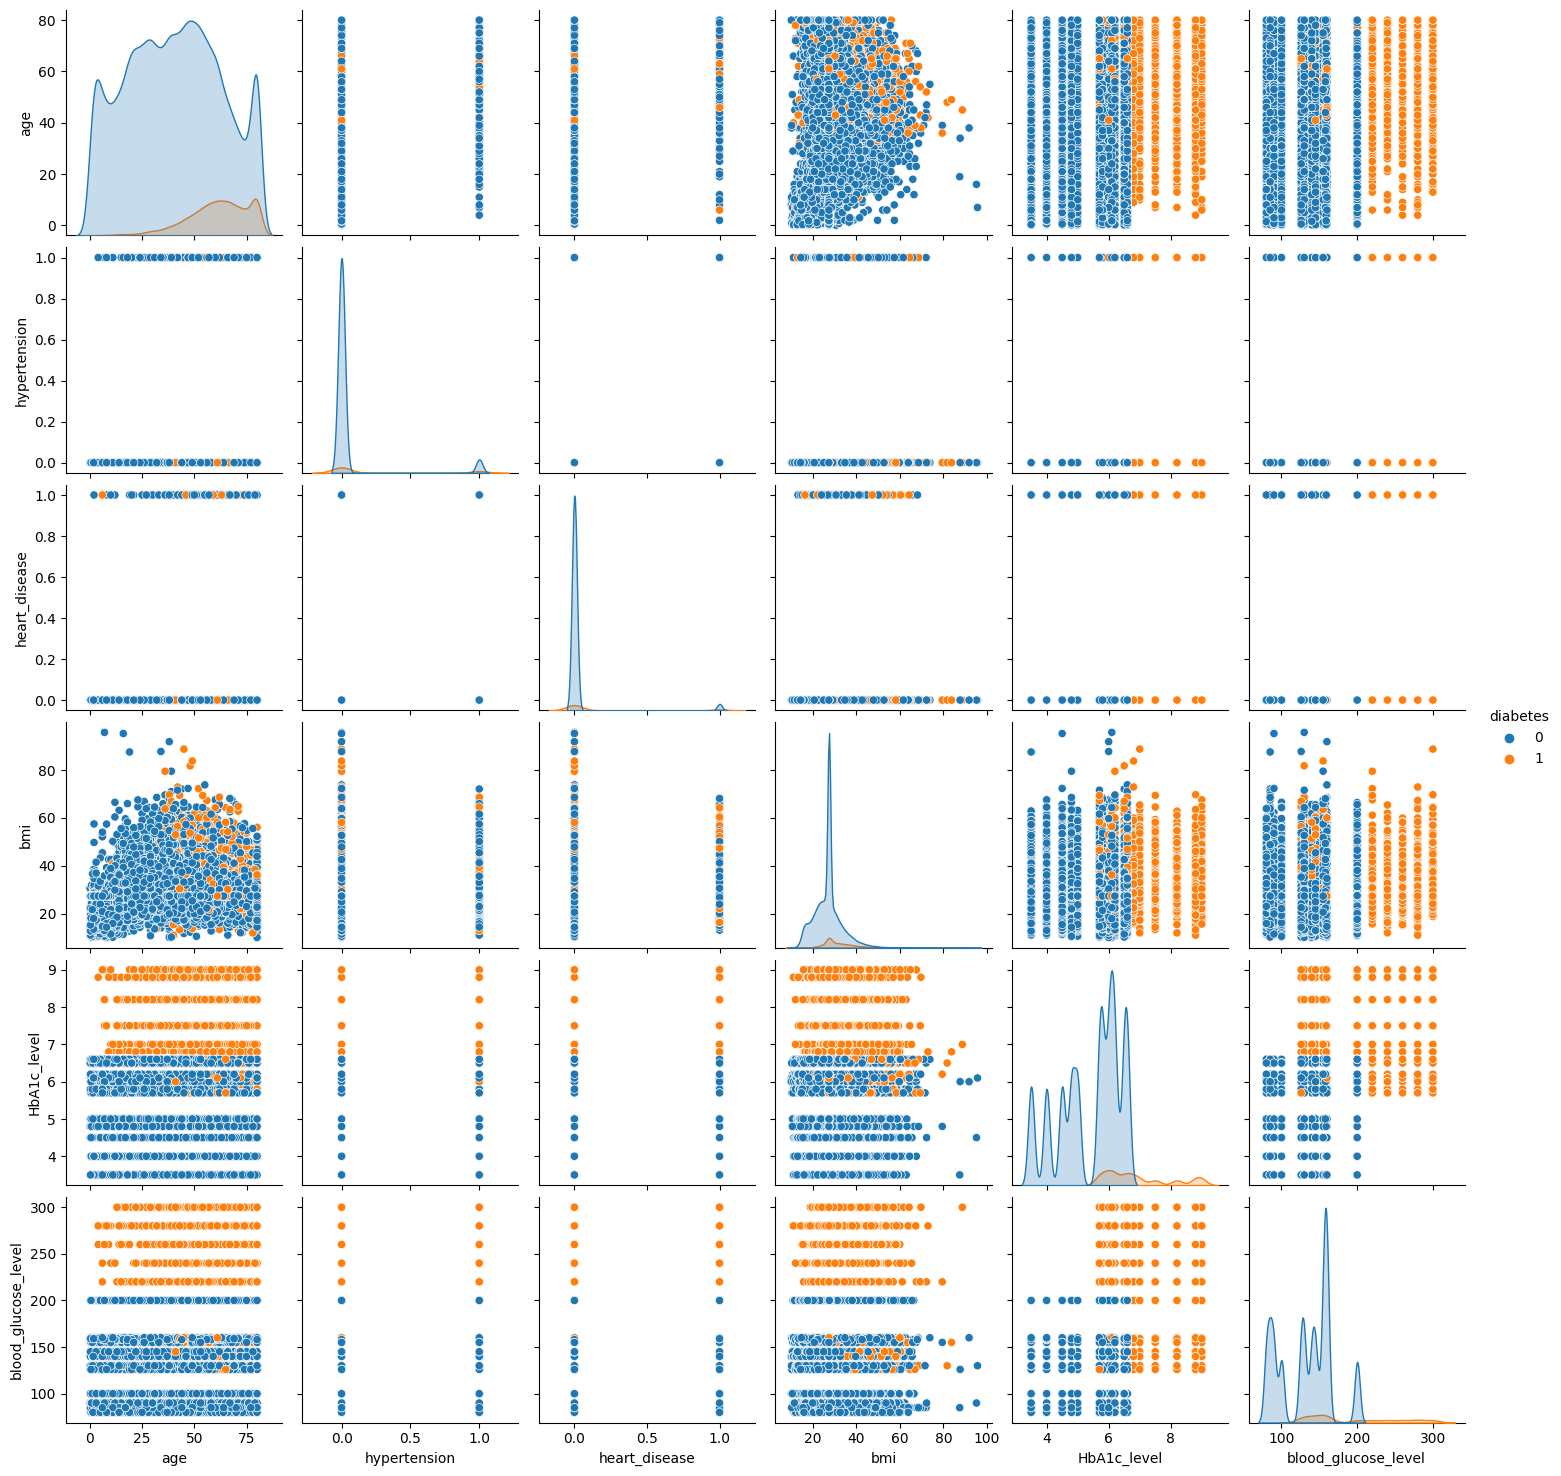

In [ ]:
sns.pairplot(data = df_train_copy,hue = 'diabetes')
plt.show()

A partir de los mismos, se pudo corroborar lo que se conoce teóricamente: por un lado, existe cierta correlación entre personas con alto nivel de HbA1c y aquellas que presentan alto nivel de glucosa en sangre; y por otro, analizando las distribución de edades de quienes poseen diabetes, la mayoría tiene edades que superan los 50 años.

In [ ]:
def num_to_cat(df,columns):
    for column in columns:
        df[column] = df[column].replace({0: 'Negativo', 1: 'Positivo'})
    return df

In [ ]:
columns_to_convert = ['hypertension', 'heart_disease', 'diabetes']
df_train_copy = num_to_cat(df_train_copy,columns_to_convert)
df_test_copy = num_to_cat(df_test_copy,columns_to_convert)

## Análisis y exploración de los datos

A continuación se analiza si existen desbalances en cuanto a `clase`, `género`y `edad`.

### Clase

In [ ]:
def plot_bar_chart(df, column_name):
    conteo = df[column_name].value_counts()
    total_instances = len(df)
    porcentajes = conteo / total_instances * 100

    plt.figure(figsize=(8, 6))
    sns.barplot(x=conteo.index, y=conteo.values, edgecolor='black')

    plt.xticks(rotation=0)
    for index, value in enumerate(conteo):
        percentage = porcentajes.iloc[index]
        plt.text(index, value, f"{percentage:.2f}%", ha='center', va='bottom', fontsize=12)

    plt.title(f"Cantidad de instancias en la columna {column_name}")
    plt.ylabel("Cantidad")

    plt.tight_layout()
    plt.show()

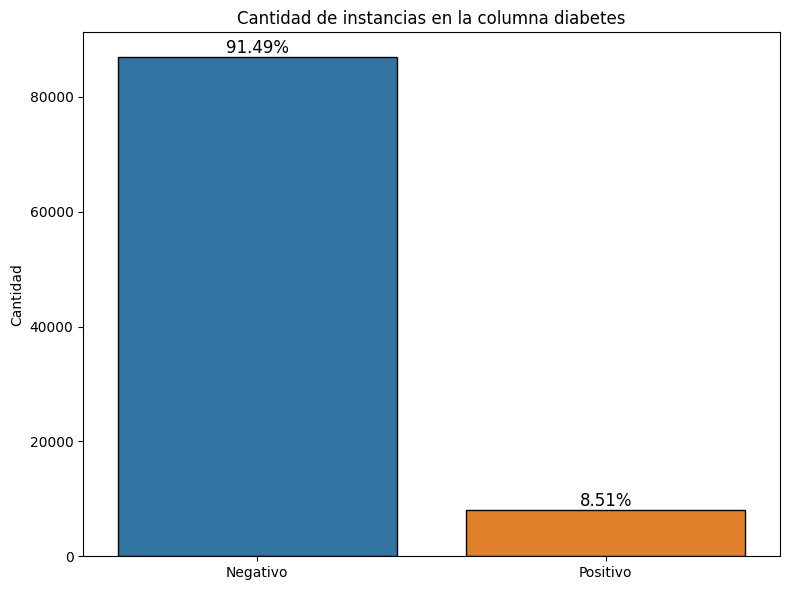

In [ ]:
plot_bar_chart(df_train_copy, 'diabetes')

En base al gráfico anterior, es posible observar que las clases mostradas en el mismo están desbalanceadas. Además, es posible ver que del 100% de las personas censadas, el 8.51% presenta diabetes mientras que el restante 91.49% no. En función a esto, se puede deducir que cualquer modelo que se utilice, reconocerá mejor casos Negativos, que Positivos.

In [ ]:
def plot_categorical(df1, df2):

    cat_columns_df1 = df1.select_dtypes(include='object').columns
    cat_columns_df2 = df2.select_dtypes(include='object').columns
    cat_columns = list(set(cat_columns_df1).intersection(cat_columns_df2))

    for col in cat_columns:

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        ax1 = axes[0]
        sns.countplot(data=df1, x=col, ax=ax1)

        ax2 = axes[1]
        sns.countplot(data=df2, x=col, ax=ax2)

        total_counts_df1 = len(df1[col])
        for p in ax1.patches:
            height = p.get_height()
            percentage = (height / total_counts_df1) * 100
            ax1.annotate(f'{percentage:.2f}%', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=12)

        total_counts_df2 = len(df2[col])
        for p in ax2.patches:
            height = p.get_height()
            percentage = (height / total_counts_df2) * 100
            ax2.annotate(f'{percentage:.2f}%', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=12)

        ax1.set_title(f"Datos de Entrenamiento\nCantidad de instancias en la columna {col}")
        ax1.set_xlabel(col)
        ax1.set_ylabel("Cantidad")

        ax2.set_title(f"Datos de Prueba\nCantidad de instancias en la columna {col}")
        ax2.set_xlabel(col)
        ax2.set_ylabel("Cantidad")

    plt.tight_layout()
    plt.show()

Dado que se entrenará un modelo con un conjunto de datos para luego hacer prediciones sobre un conjunto distinto, se analizaron las distribuciones de instancias de las variables categoricas de ambos, para asegurar que el modelo construído se comporte de manera similar sobre ambos conjuntos de datos.

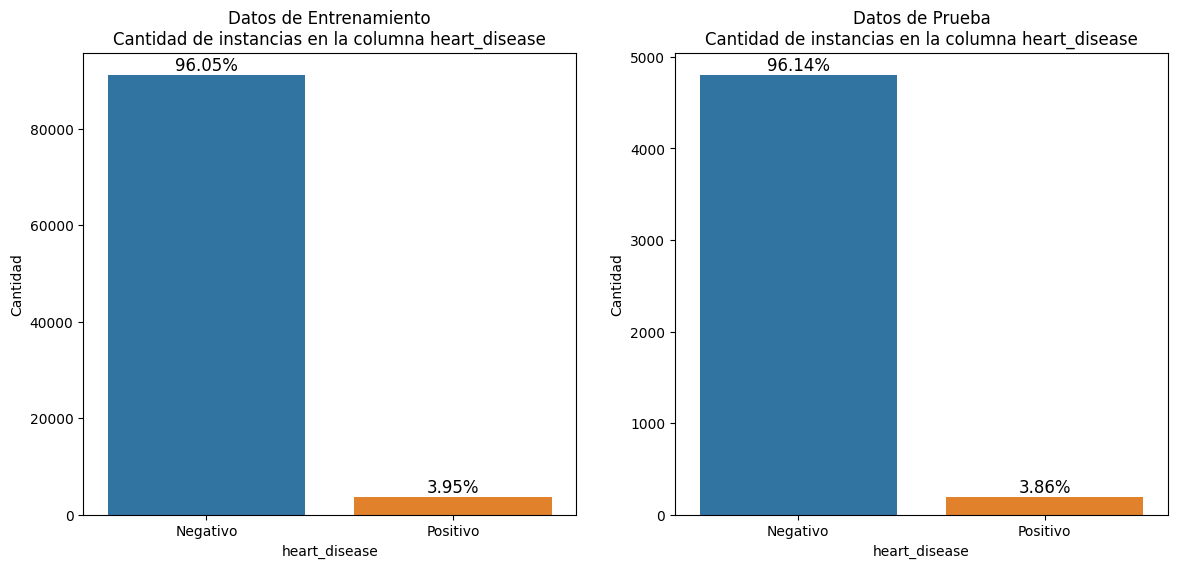

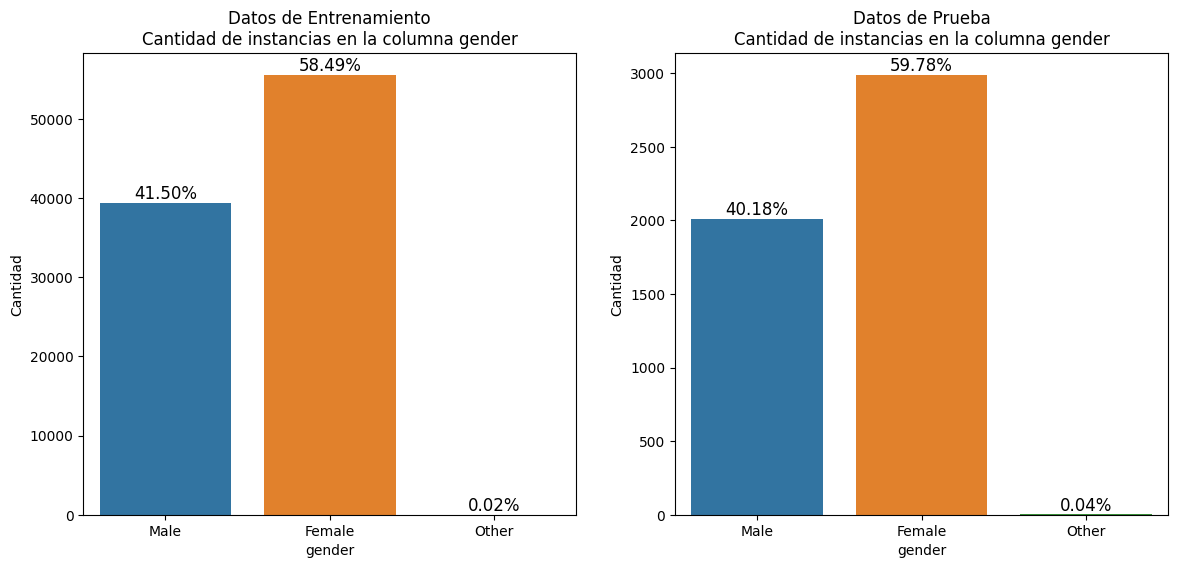

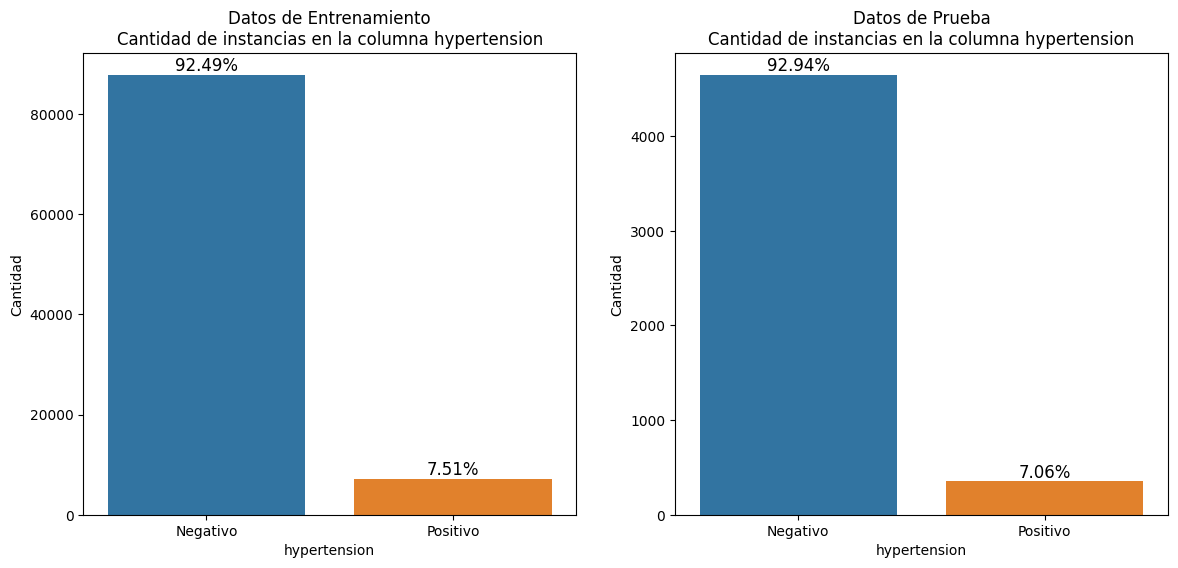

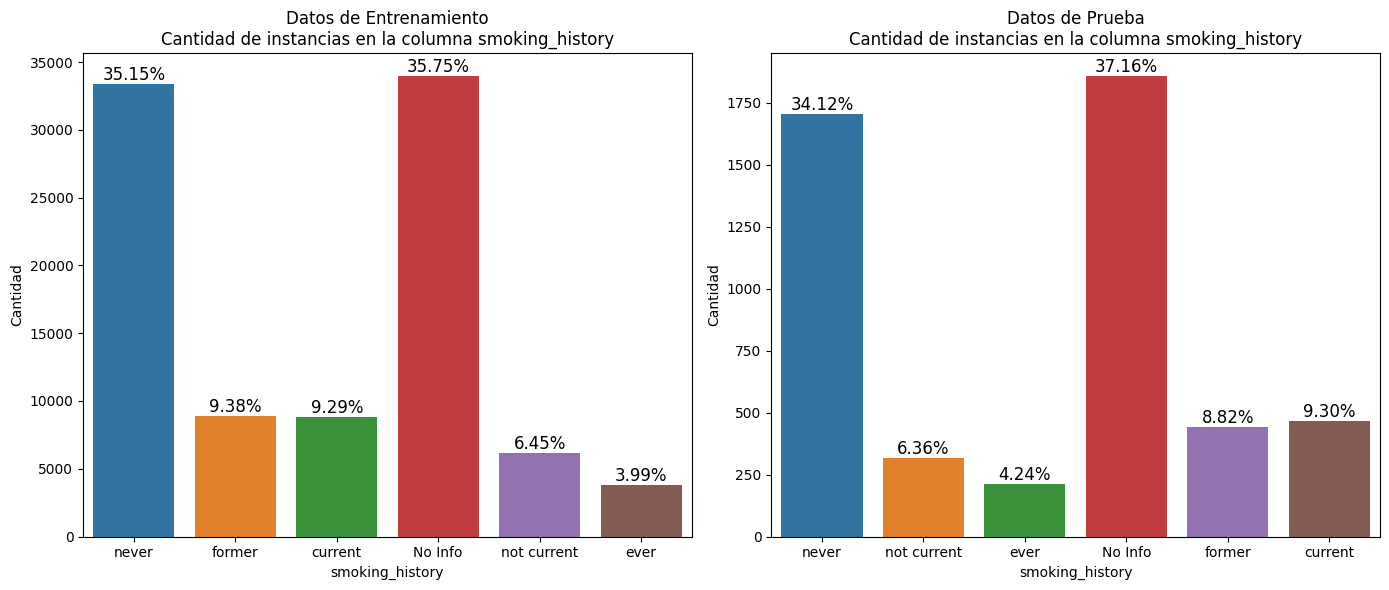

In [ ]:
plot_categorical(df_train_copy, df_test_copy)

Puede decirse que las distribuciones son similares. Se procedio a analizar las distribuciones del set de entrenamiento, diferenciando segun la columna `diabetes`.

### Género

In [ ]:
def plot_categorical_hue(df, name_column):
    columns = df.select_dtypes(include='object').columns
    for col in columns:
        fig = plt.figure(figsize=(10, 6))
        ax = sns.countplot(data=df, x=col, hue=name_column)

        total_counts = len(df[name_column])
        for p in ax.patches:
            height = p.get_height()
            percentage = (height / total_counts) * 100
            ax.annotate(f'{percentage:.2f}%', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=12)

        plt.title(f"Cantidad de instancias en la columna {col}")
        plt.xlabel(col)
        plt.ylabel("Cantidad")

        plt.show()

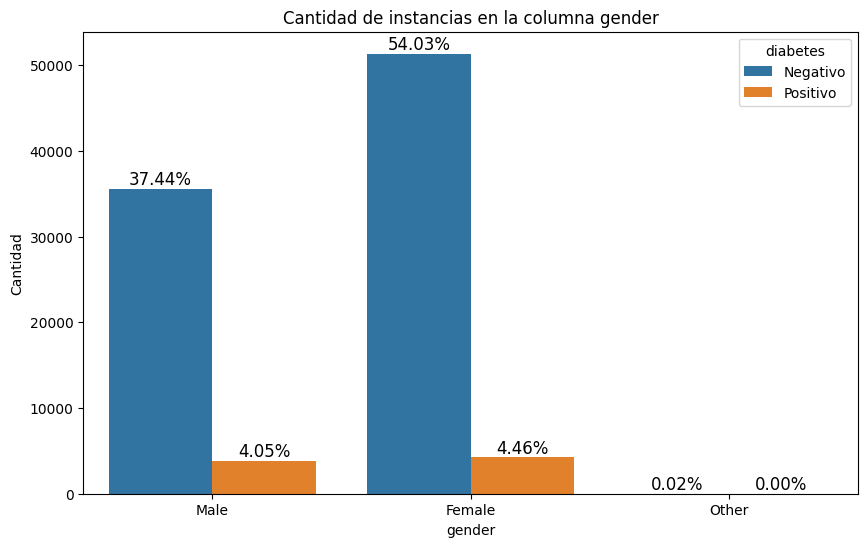

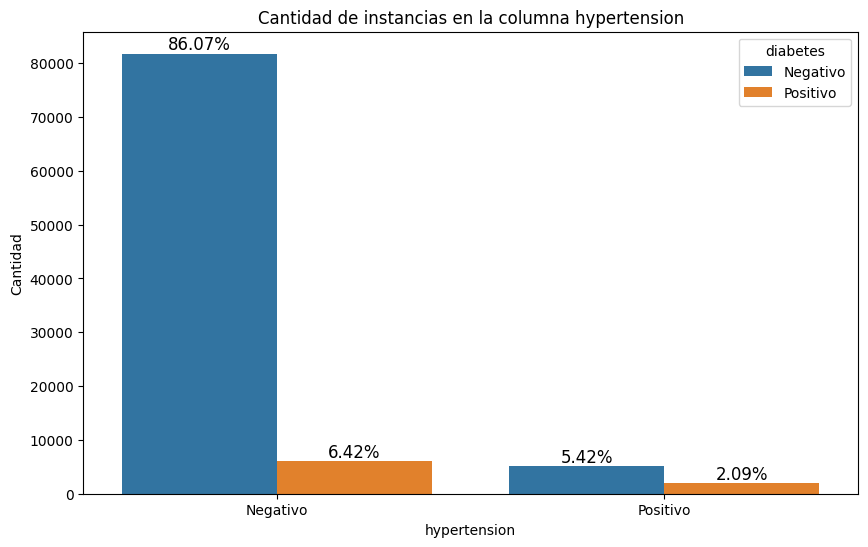

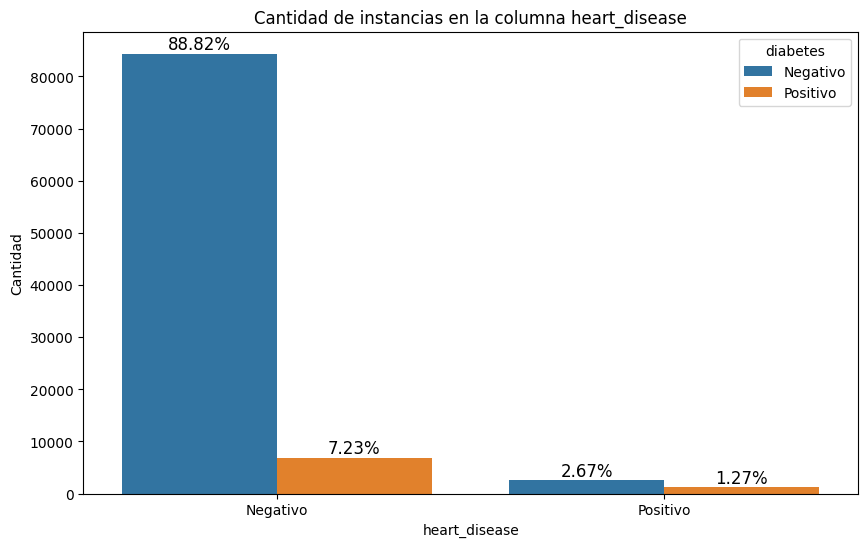

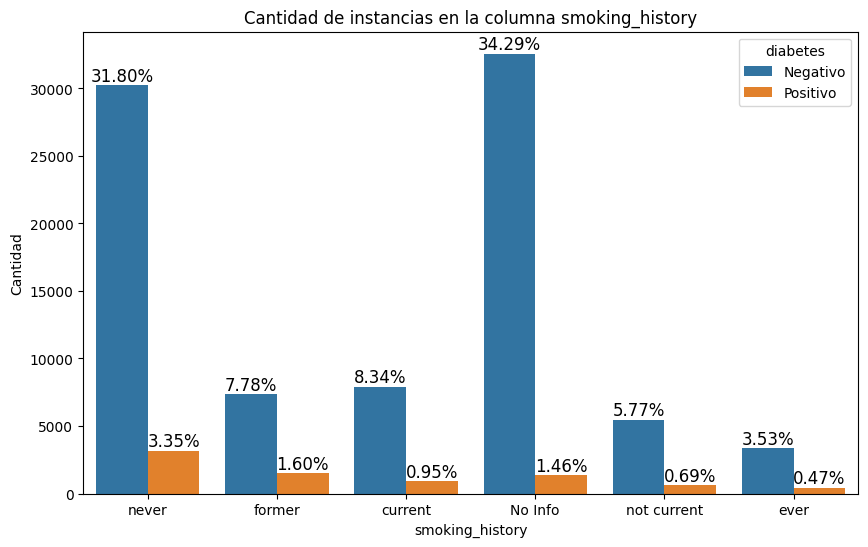

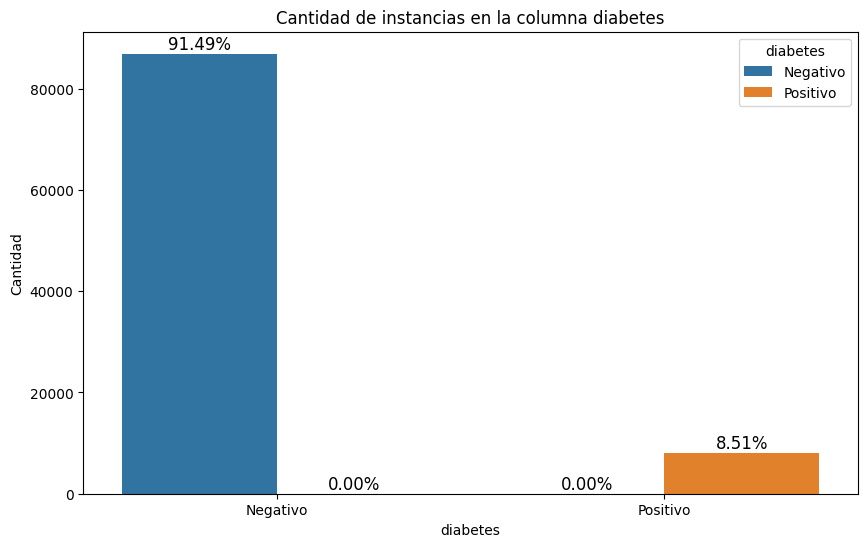

In [ ]:
plot_categorical_hue(df_train_copy, 'diabetes')

El primer gráfico de la salida anterior (correspondiente a `Género`) indica, por un lado, que la prevalencia de la enfermedad es similar tanto en hombres como en mujeres; y por el otro, que el porcentaje de personas con diabetes dentro del género es significativamente menor.

Por otra parte, es posible observar que la cantidad de datos de otros géneros es muy pequeña. Sin embargo, se decidió no elimiminar dichos datos debido a que son escasos y no generarían inconvenientes al momento de crear los modelos ni tendrían implicancias significativas en las conclusiones obtenidas.

Asimismo, utilizando el mismo código, se analizaron las distribuciones de las variables numéricas de ambos set de datos tal como se había mencionado previamente.

### Edad

In [ ]:
def plot_numerical(df1, df2):

    num_columns_df1 = df1.select_dtypes(include='number').columns
    num_columns_df2 = df2.select_dtypes(include='number').columns
    num_columns = list(set(num_columns_df1).intersection(num_columns_df2))

    for col in num_columns:

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        ax1 = axes[0]
        sns.histplot(data=df1, x=col, bins='auto', ax=ax1)

        ax2 = axes[1]
        sns.histplot(data=df2, x=col, bins='auto', ax=ax2)

        ax1.set_title(f"Datos de Entrenamiento\nCantidad de instancias en la columna {col}")
        ax1.set_xlabel(col)
        ax1.set_ylabel("Cantidad")

        ax2.set_title(f"Datos de Prueba\nCantidad de instancias en la columna {col}")
        ax2.set_xlabel(col)
        ax2.set_ylabel("Cantidad")

    plt.tight_layout()
    plt.show()

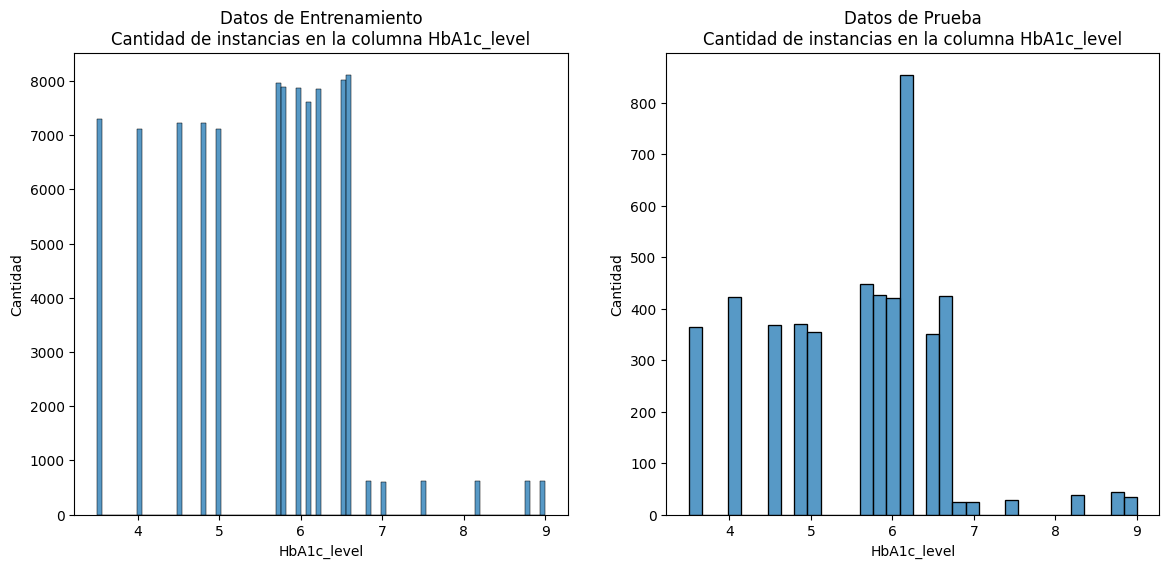

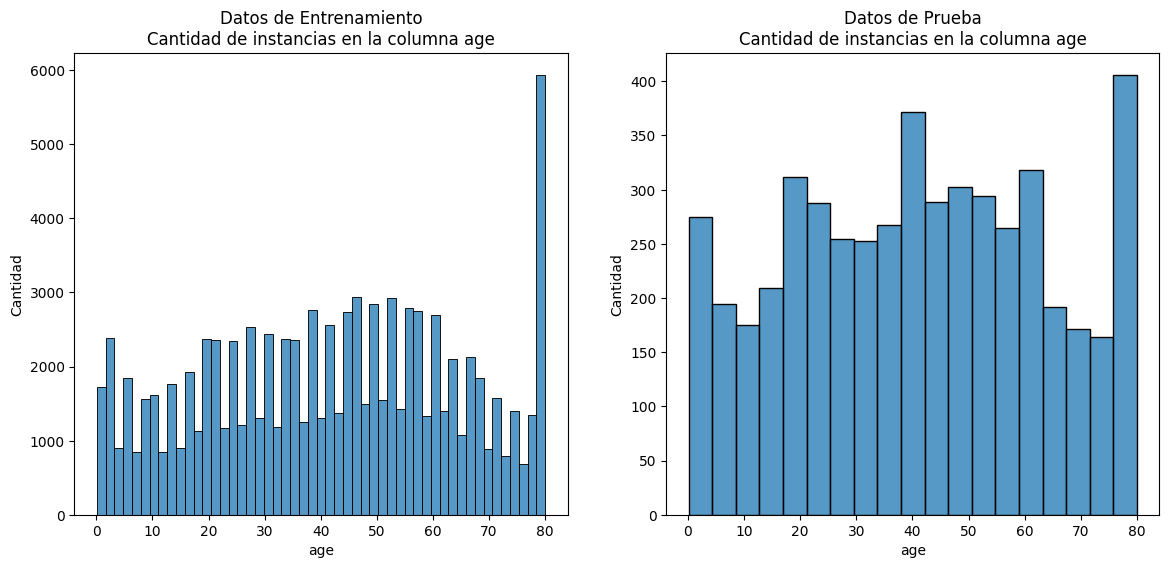

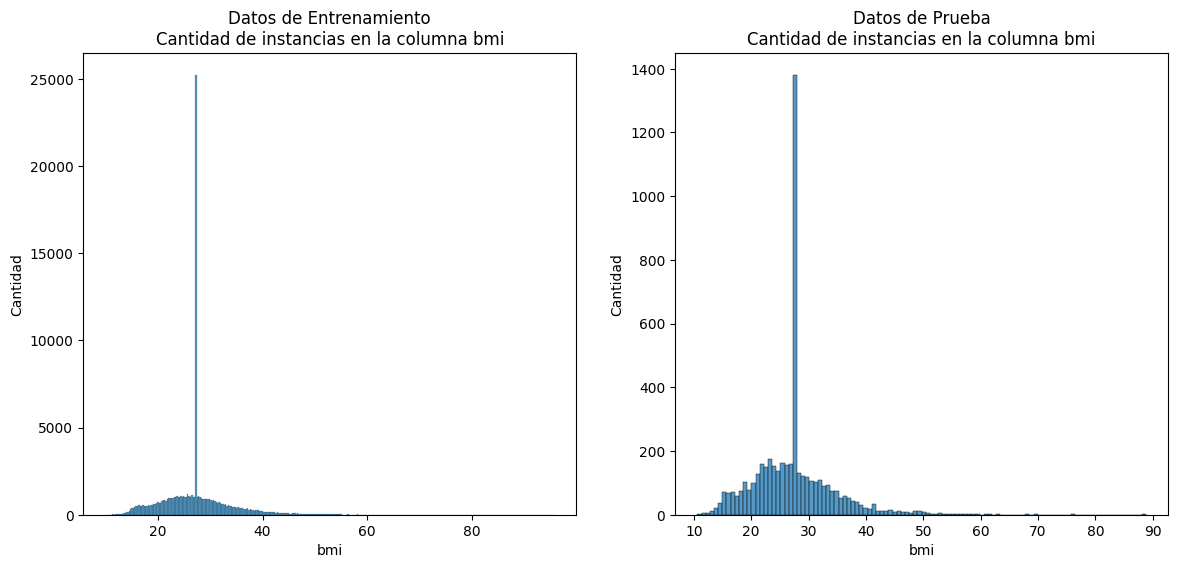

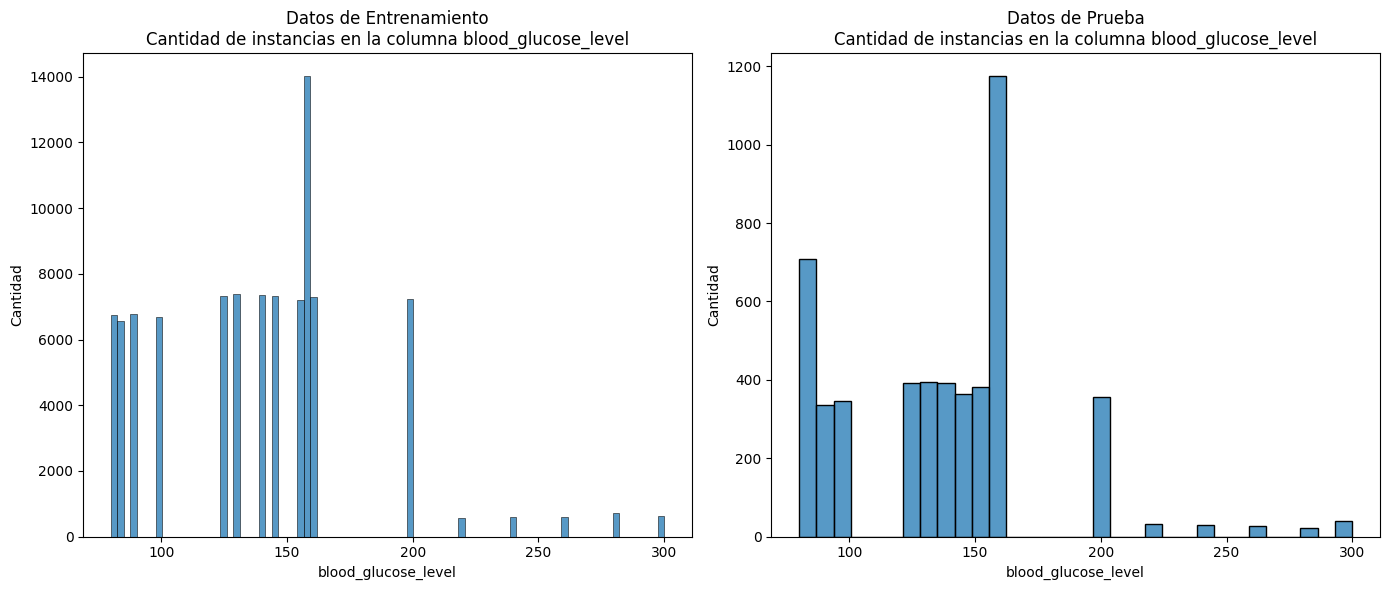

In [ ]:
plot_numerical(df_train_copy, df_test_copy)

Nuevamente, se corroboró que las distribuciones de las variables numéricas son similares, por lo que se puede asegurar que el modelo a utilizar replicará sus resultados sobre el set de datos de prueba.

Los gráficos de la salida anterior correspondientes a `age` indican (al igual que en el pairplot) que la presencia de diabetes presenta una frecuencia más alta a medida que las personas tienen mayor edad.

In [ ]:
X = df_train.drop('diabetes',axis=1)
y = df_train.diabetes

In [ ]:
X

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,20432,Male,4.0,0,0,never,19.28,3.5,155
1,49682,Female,50.0,0,0,former,27.32,5.7,159
2,73886,Female,43.0,0,0,never,21.54,4.5,145
3,53144,Male,64.0,0,0,current,28.22,6.0,130
4,98507,Male,10.0,0,0,No Info,15.46,6.1,140
...,...,...,...,...,...,...,...,...,...
94995,81090,Female,56.0,0,0,never,22.30,6.2,158
94996,90924,Female,24.0,0,0,never,22.50,6.1,126
94997,64600,Female,32.0,0,0,never,24.92,6.6,145
94998,96132,Female,21.0,0,0,current,20.59,4.5,155


In [ ]:
y

0        0
1        0
2        0
3        0
4        0
        ..
94995    0
94996    0
94997    0
94998    0
94999    0
Name: diabetes, Length: 95000, dtype: int64

Se eliminó la columna con los Id de los pacientes en una sola variable:

In [ ]:
X.drop('patient',axis=1,inplace=True)

Se transformaron variables categóricas a númericas, como por ejemplo **gender** y **smoking_history**.

In [ ]:
X['smoking_history'].unique()

array(['never', 'former', 'current', 'No Info', 'not current', 'ever'],
      dtype=object)

In [ ]:
X['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [ ]:
X_encoded = pd.get_dummies(X, columns=['gender', 'smoking_history'], prefix=['gender', 'smoke'])
X_encoded

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Female,gender_Male,gender_Other,smoke_No Info,smoke_current,smoke_ever,smoke_former,smoke_never,smoke_not current
0,4.0,0,0,19.28,3.5,155,0,1,0,0,0,0,0,1,0
1,50.0,0,0,27.32,5.7,159,1,0,0,0,0,0,1,0,0
2,43.0,0,0,21.54,4.5,145,1,0,0,0,0,0,0,1,0
3,64.0,0,0,28.22,6.0,130,0,1,0,0,1,0,0,0,0
4,10.0,0,0,15.46,6.1,140,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94995,56.0,0,0,22.30,6.2,158,1,0,0,0,0,0,0,1,0
94996,24.0,0,0,22.50,6.1,126,1,0,0,0,0,0,0,1,0
94997,32.0,0,0,24.92,6.6,145,1,0,0,0,0,0,0,1,0
94998,21.0,0,0,20.59,4.5,155,1,0,0,0,1,0,0,0,0


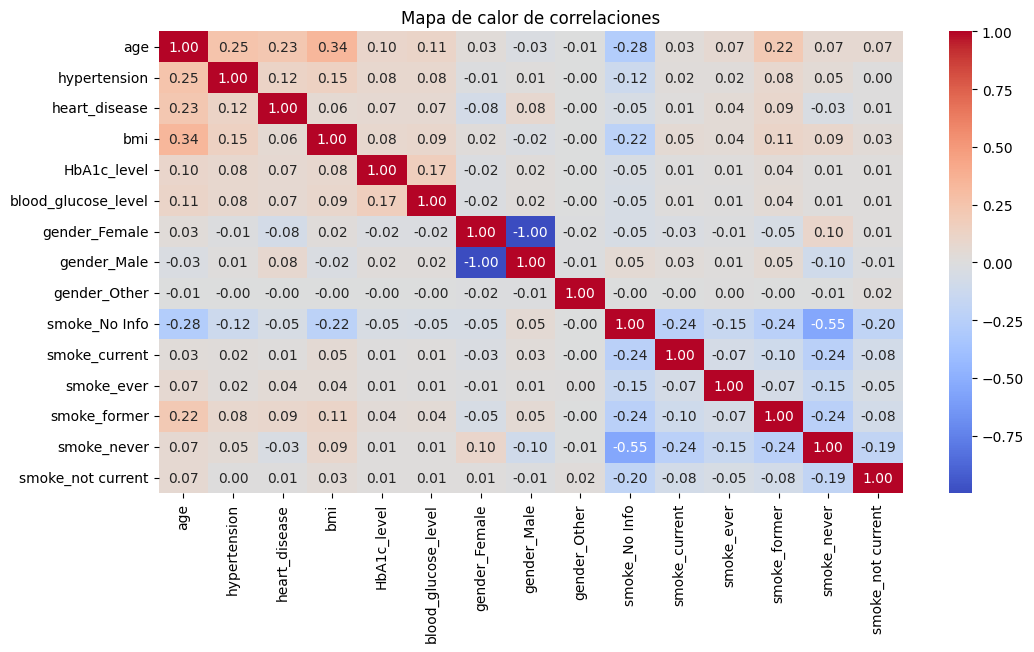

In [ ]:
correlations = X_encoded.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 6))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={'size': 10})
plt.title("Mapa de calor de correlaciones")
plt.show()

Se realizó un mapa de calor de correlación entre las variables para reducir el número de variables a incluir en la construcción del modelo.

Como resultado, las variables que más correlación positiva presentaron fueron:

*   `bmi` y `age` (0.34)
*   `hypertension` y `age` (0.25)
*   `heart_disease` y `age` (0.23)

En otras palabras, el Índice de Masa Corporal (`bmi`), la hipertensión (`hypertension`) y los problemas cardíacos (`heart_disease`) aumentan con el correr de los años.




Se estandarizaron las variables:

In [ ]:
x_names = X_encoded.columns
X_standar = StandardScaler().fit_transform(X_encoded)
X_standar = pd.DataFrame(X_standar, columns=x_names)
X_standar

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Female,gender_Male,gender_Other,smoke_No Info,smoke_current,smoke_ever,smoke_former,smoke_never,smoke_not current
0,-1.684913,-0.284899,-0.202693,-1.213479,-1.894556,0.415552,-1.186973,1.187385,-0.012979,-0.745859,-0.319932,-0.2039,-0.321728,1.358399,-0.262612
1,0.358199,-0.284899,-0.202693,-0.000133,0.161028,0.513736,0.842479,-0.842187,-0.012979,-0.745859,-0.319932,-0.2039,3.108212,-0.736161,-0.262612
2,0.047291,-0.284899,-0.202693,-0.872414,-0.960200,0.170091,0.842479,-0.842187,-0.012979,-0.745859,-0.319932,-0.2039,-0.321728,1.358399,-0.262612
3,0.980016,-0.284899,-0.202693,0.135690,0.441335,-0.198100,-1.186973,1.187385,-0.012979,-0.745859,3.125661,-0.2039,-0.321728,-0.736161,-0.262612
4,-1.418420,-0.284899,-0.202693,-1.789970,0.534771,0.047361,-1.186973,1.187385,-0.012979,1.340736,-0.319932,-0.2039,-0.321728,-0.736161,-0.262612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94995,0.624692,-0.284899,-0.202693,-0.757720,0.628206,0.489190,0.842479,-0.842187,-0.012979,-0.745859,-0.319932,-0.2039,-0.321728,1.358399,-0.262612
94996,-0.796604,-0.284899,-0.202693,-0.727537,0.534771,-0.296284,0.842479,-0.842187,-0.012979,-0.745859,-0.319932,-0.2039,-0.321728,1.358399,-0.262612
94997,-0.441280,-0.284899,-0.202693,-0.362326,1.001949,0.170091,0.842479,-0.842187,-0.012979,-0.745859,-0.319932,-0.2039,-0.321728,1.358399,-0.262612
94998,-0.929850,-0.284899,-0.202693,-1.015782,-0.960200,0.415552,0.842479,-0.842187,-0.012979,-0.745859,3.125661,-0.2039,-0.321728,-0.736161,-0.262612


A partir de los datos en las variables `X` e `y` se separó en *train* y en *test*.

Se crearon dos set de datos de entrenamiento y prueba: uno se hizo con los datos estandarizados y otro sin estandarizar. Esto se hizo debido a que hay modelos que no requieren ser entrenados con datos estandarizados. De igual forma, se probaron dichos modelos con ambos set de datos para ver si existía alguna diferencia.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, train_size=0.8, random_state = 0, stratify=y)
X_train_std, X_test_std, y_train_std, y_test_std = train_test_split(X_standar, y, train_size=0.8, random_state = 0, stratify=y)

## Planteo de modelos


Se probaron los modelos que se especifican a continuación:

- Regresión Logística
- Perceptron
- KNeighborsClassifier
- SVC
- RandomForestClassifier
- AdaBoostClassifier
- GradientBoostingClassifier
- XGBClassifier
- XGBRFClassifier


In [ ]:
name_trained_models = []
train_accuracy_models = []
test_accuracy_models = []

Primero se analizaron los modelos que usan datos estandarizados.

In [ ]:
clfs_std = [LogisticRegression(),
            Perceptron(),
            KNeighborsClassifier(),
            SVC(),
            RandomForestClassifier(),
            AdaBoostClassifier(),
            GradientBoostingClassifier(),
            XGBClassifier(),
            XGBRFClassifier()
        ]
names_std = ['Regresion Logistica',
             'Perceptron',
             'KNeighborsClassifier (Datos Estandarizados)',
             'SVC(Support Vector Classifier)',
             'Random-Forest (Datos Estandarizados)',
             'AdaBoostClassifier (Datos Estandarizados)',
             'GradientBoostingClassifier (Datos Estandarizados)',
             'XGBClassifier (Datos Estandarizados)',
             'XGBRFClassifier (Datos Estandarizados)'
         ]

for clf,name in zip(clfs_std,names_std):

    print(name)
    clf.fit(X_train_std, y_train_std)

    train_predictions = clf.predict(X_train_std)
    train_accuracy = accuracy_score(y_train_std, train_predictions)
    print(f"Accuracy train : %.2f%%" % (train_accuracy * 100.0))

    test_predictions = clf.predict(X_test_std)
    test_accuracy = accuracy_score(y_test_std, test_predictions)
    print(f"Accuracy test : %.2f%%" % (test_accuracy * 100.0))
    print('')


    name_trained_models.append(name)
    train_accuracy_models.append(round(train_accuracy*100,2))
    test_accuracy_models.append(round(test_accuracy*100,2))

Regresion Logistica
Accuracy train : 96.04%
Accuracy test : 95.99%

Perceptron
Accuracy train : 93.51%
Accuracy test : 93.48%

KNeighborsClassifier (Datos Estandarizados)
Accuracy train : 96.88%
Accuracy test : 96.11%

SVC(Support Vector Classifier)
Accuracy train : 96.35%
Accuracy test : 96.30%

Random-Forest (Datos Estandarizados)
Accuracy train : 99.92%
Accuracy test : 97.03%

AdaBoostClassifier (Datos Estandarizados)
Accuracy train : 97.17%
Accuracy test : 97.28%

GradientBoostingClassifier (Datos Estandarizados)
Accuracy train : 97.20%
Accuracy test : 97.31%

XGBClassifier (Datos Estandarizados)
Accuracy train : 97.55%
Accuracy test : 97.15%

XGBRFClassifier (Datos Estandarizados)
Accuracy train : 97.17%
Accuracy test : 97.25%



Luego se analizaron los que no requieren datos estandarizados.

In [ ]:
clfs = [RandomForestClassifier(),
        KNeighborsClassifier(),
        AdaBoostClassifier(),
        GradientBoostingClassifier(),
        XGBClassifier(),
        XGBRFClassifier()
        ]
names = ['Random-Forest (Datos sin Estandarizar)',
         'KNeighborsClassifier (Datos sin Estandarizar)',
         'AdaBoostClassifier (Datos sin Estandarizar)',
         'GradientBoostingClassifier (Datos sin Estandarizar)',
         'XGBClassifier (Datos sin Estandarizar)',
         'XGBRFClassifier (Datos sin Estandarizar)'
         ]

for clf,name in zip(clfs,names):

    print(name)
    clf.fit(X_train, y_train)

    train_predictions = clf.predict(X_train)
    train_accuracy = accuracy_score(y_train, train_predictions)
    print(f"Accuracy train : %.2f%%" % (train_accuracy * 100.0))

    test_predictions = clf.predict(X_test)
    test_accuracy = accuracy_score(y_test, test_predictions)
    print(f"Accuracy test : %.2f%%" % (test_accuracy * 100.0))
    print('')

    name_trained_models.append(name)
    train_accuracy_models.append(round(train_accuracy*100,2))
    test_accuracy_models.append(round(test_accuracy*100,2))

Random-Forest (Datos sin Estandarizar)
Accuracy train : 99.92%
Accuracy test : 96.99%

KNeighborsClassifier (Datos sin Estandarizar)
Accuracy train : 96.32%
Accuracy test : 95.47%

AdaBoostClassifier (Datos sin Estandarizar)
Accuracy train : 97.17%
Accuracy test : 97.28%

GradientBoostingClassifier (Datos sin Estandarizar)
Accuracy train : 97.20%
Accuracy test : 97.31%

XGBClassifier (Datos sin Estandarizar)
Accuracy train : 97.55%
Accuracy test : 97.15%

XGBRFClassifier (Datos sin Estandarizar)
Accuracy train : 97.17%
Accuracy test : 97.25%



In [ ]:
models = pd.DataFrame({'Test Accuracy': test_accuracy_models,
                       'Train Accuracy': train_accuracy_models},
                      index = name_trained_models).sort_values(by = 'Test Accuracy', ascending=False)
models

,Test Accuracy,Train Accuracy
GradientBoostingClassifier (Datos Estandarizados),97.31,97.20
GradientBoostingClassifier (Datos sin Estandarizar),97.31,97.20
AdaBoostClassifier (Datos Estandarizados),97.28,97.17
AdaBoostClassifier (Datos sin Estandarizar),97.28,97.17
XGBRFClassifier (Datos Estandarizados),97.25,97.17
XGBRFClassifier (Datos sin Estandarizar),97.25,97.17
XGBClassifier (Datos Estandarizados),97.15,97.55
XGBClassifier (Datos sin Estandarizar),97.15,97.55
Random-Forest (Datos Estandarizados),97.03,99.92
Random-Forest (Datos sin Estandarizar),96.99,99.92


En función a este ranking de *accuracy* para cada modelo, se vio que los modelos `GradientBoostingClassifier`, `AdaBoostClassifier`, `XGBRFClassifier`, `RandomForestClassifier` son los que mejor rendimiento tienen sobre datos de prueba.

Cabe aclarar que se eligió tener en cuenta solo el *accuracy* sobre los datos de prueba. Esto se hizo porque se buscaron aquellos modelos que tuvieran un mejor rendimiento sobre datos que no hubieran sido vistos durante el entrenamiento.

Además, es posible notar que estos cuatro modelos no tienen diferencias de rendimiento entre datos estandarizados y sin estandarizar. Por simplicidad y para no sobrecargar de transformaciones los datos, se decidió trabajar entonces con datos sin estandarizar.

Se tomaron luego estos modelos para analizar y ver cuáles eran los resultados obtenidos.

In [ ]:
modelos = [GradientBoostingClassifier(),
           AdaBoostClassifier(),
           XGBRFClassifier(),
           RandomForestClassifier()
           ]
nombres = ['GradientBoostingClassifier',
           'AdaBoostClassifier',
           'XGBRFClassifier',
           'RandomForestClassifier'
           ]

En primer lugar se calcularon las métricas de estos cuatro modelos con sus parámetros por defecto para tener un punto de referencia en base a los cuales poder hacer comparaciones.

Además, se creó una lista llamada `matrix_conf` donde se fueron guardando las matrices de confusión de cada modelo para luego hacer un análisis más detallado.

In [ ]:
matrix_conf = []

for modelo in modelos:

    clf = modelo.fit(X_train, y_train)

    # Predicciones en el conjunto de entrenamiento y cálculo de la precisión
    clf_train_pred = clf.predict(X_train)
    clf_train_accu = accuracy_score(y_train, clf_train_pred)
    print(f"Accuracy train del modelo {modelo.__class__.__name__} : {clf_train_accu * 100:.2f}%")

    # Predicciones en el conjunto de prueba y cálculo de la precisión
    clf_test_pred = clf.predict(X_test)
    clf_test_accu = accuracy_score(y_test, clf_test_pred)
    print(f"Accuracy test del modelo {modelo.__class__.__name__} : {clf_test_accu * 100:.2f}%")
    print('')

    # Matriz de confusión y reporte de clasificación
    conf_matrix = confusion_matrix(y_test, clf_test_pred)
    matrix_conf.append(conf_matrix)

    print(f"Reporte de clasificación para {modelo.__class__.__name__} :")
    print(classification_report(y_test, clf_test_pred))
    print("---------------------------------------------------------------------")

Accuracy train del modelo GradientBoostingClassifier : 97.20%
Accuracy test del modelo GradientBoostingClassifier : 97.31%

Reporte de clasificación para GradientBoostingClassifier :
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     17384
           1       0.99      0.69      0.81      1616

    accuracy                           0.97     19000
   macro avg       0.98      0.85      0.90     19000
weighted avg       0.97      0.97      0.97     19000

---------------------------------------------------------------------
Accuracy train del modelo AdaBoostClassifier : 97.17%
Accuracy test del modelo AdaBoostClassifier : 97.28%

Reporte de clasificación para AdaBoostClassifier :
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     17384
           1       0.97      0.70      0.81      1616

    accuracy                           0.97     19000
   macro avg       0.97      0.85      0.90

Para poder obtener un valor para el *accuracy* más confiable y robusto, se usó la técnica de Validación Cruzada (Cross-Validation). Estos valores son los que se tuvieron en cuenta para hacer la comparación de los rendimientos de los distintos modelos que se analizaron.

In [ ]:
FOLDS=5
cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=10)

x_train2 = np.array(X_train)
y_train2 = np.array(y_train)

defec_accu = []

for clfi, name in zip(modelos,nombres):

    print(f'{name} :\n')
    avg_accuracy = 0

    for fold, (train_idx, val_idx) in enumerate(cv.split(x_train2, y_train2)):
        xi, yi = x_train2[train_idx], y_train2[train_idx]
        x_valid, y_valid = x_train2[val_idx], y_train2[val_idx]
        clfi = clfi.fit(xi, yi)

        test_predictions = clfi.predict(x_valid)
        accuracy = accuracy_score(y_valid, test_predictions)
        avg_accuracy +=accuracy
        print(f"Precisión test fold {fold + 1}: {accuracy * 100.0 :.2f}" % ())

    avg_accuracy /= FOLDS
    defec_accu.append(round(avg_accuracy * 100, 2))
    print(f'Avg. accuracy = {avg_accuracy * 100.0 :.2f}\n')

GradientBoostingClassifier :

Precisión test fold 1: 97.20
Precisión test fold 2: 97.09
Precisión test fold 3: 97.19
Precisión test fold 4: 97.16
Precisión test fold 5: 97.20
Avg. accuracy = 97.17

AdaBoostClassifier :

Precisión test fold 1: 97.24
Precisión test fold 2: 97.08
Precisión test fold 3: 97.23
Precisión test fold 4: 97.12
Precisión test fold 5: 97.11
Avg. accuracy = 97.16

XGBRFClassifier :

Precisión test fold 1: 97.18
Precisión test fold 2: 97.11
Precisión test fold 3: 97.20
Precisión test fold 4: 97.18
Precisión test fold 5: 97.16
Avg. accuracy = 97.17

RandomForestClassifier :

Precisión test fold 1: 97.11
Precisión test fold 2: 96.85
Precisión test fold 3: 97.01
Precisión test fold 4: 96.99
Precisión test fold 5: 97.01
Avg. accuracy = 96.99



Se notó que para cada pliegue o subconjunto de datos (`fold`) el *accuracy* fue mucho menor que el obtenido con el modelo entrenado con el set de datos "completo" (teniendo en cuenta que por "completo" se hace referencia al 80% de los datos totales de entrenamiento). Aún así, estos valores son más confiables, debido a que son el resultado de un evaluación mas exhaustiva.

### Ajuste de hiperparámetros de los modelos elegidos

Teniendo las métricas de los modelos con párametros por defecto, se procedió a probar diferentes combinaciones de parámetros y obtener sus métricas para poder ver si existe una mejora en los resultados o no.

In [ ]:
# Definir los hiperparámetros que queremos probar en la búsqueda aleatoria
gbc_param_grid_comp = {
    'learning_rate': [0.1, 0.05, 0.01, 0.001],
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'subsample': [0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

ada_param_grid_comp = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'algorithm': ['SAMME', 'SAMME.R'],
    'random_state': [0, 1, 7, 13, 37, 42, 53, 67],
}

xgbrf_param_grid_comp = {
    'learning_rate': [0.1, 0.01, 0.001],
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bynode': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'reg_lambda': [0, 1, 5, 10],
    'reg_alpha': [0, 1, 5, 10]
}

rf_param_grid_comp = {
    'n_estimators': [100, 200, 300, 400, 500],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'bootstrap': [True],
    'oob_score': [True, False],
    'warm_start': [True, False]
}


Se creó una lista donde se guaradaron los mejores parámetros hallados por el `RandomizedSearchCV`.

In [ ]:
grid_params = [gbc_param_grid_comp,
               ada_param_grid_comp,
               xgbrf_param_grid_comp,
               rf_param_grid_comp
               ]
best_params = []

# Realizar la búsqueda aleatoria con validación cruzada
for modelo, parametros in zip(modelos, grid_params):

    random_search = RandomizedSearchCV(estimator = modelo,
                                       param_distributions = parametros,
                                       n_iter = 5)
    random_search.fit(X_train, y_train)

    # Imprimir los mejores hiperparámetros y el mejor score para cada modelo
    print(f"Mejores hiperparámetros para {modelo.__class__.__name__}:")
    print(random_search.best_params_,'\n')
    best_params.append(random_search.best_params_)

    print(f"Mejor score de validación cruzada : {random_search.best_score_ * 100.0 :.2f}")

    # Obtener el modelo con los mejores hiperparámetros
    best_modelo_classifier = random_search.best_estimator_

    # Evaluar el modelo en el conjunto de prueba
    accuracy = best_modelo_classifier.score(X_test, y_test)
    print(f"Accuracy del conjunto de prueba : {accuracy * 100.0 :.2f}\n")

Mejores hiperparámetros para GradientBoostingClassifier:
{'subsample': 0.9, 'n_estimators': 150, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5, 'learning_rate': 0.05} 

Mejor score de validación cruzada : 97.17
Accuracy del conjunto de prueba : 97.29

Mejores hiperparámetros para AdaBoostClassifier:
{'random_state': 0, 'n_estimators': 150, 'learning_rate': 1.0, 'algorithm': 'SAMME.R'} 

Mejor score de validación cruzada : 97.17
Accuracy del conjunto de prueba : 97.29

Mejores hiperparámetros para XGBRFClassifier:
{'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 5, 'n_estimators': 150, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.001, 'colsample_bytree': 0.8, 'colsample_bynode': 1.0} 

Mejor score de validación cruzada : 97.17
Accuracy del conjunto de prueba : 97.25

Mejores hiperparámetros para RandomForestClassifier:
{'warm_start': False, 'oob_score': False, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_

Una vez que se obtuvieron los mejores parámetros para cada modelo, se procedio a calcular sus métricas.

In [ ]:
for modelo, params in zip(modelos, best_params):

    clf_opt = modelo.set_params(**params).fit(X_train, y_train)

    # Predicciones en el conjunto de entrenamiento y cálculo de la precisión
    clf_opt_train_pred = clf_opt.predict(X_train)
    clf_opt_train_accu = accuracy_score(y_train, clf_opt_train_pred)
    print(f"Accuracy train del modelo {modelo.__class__.__name__} optimizado: {clf_opt_train_accu * 100:.2f}%")

    # Predicciones en el conjunto de prueba y cálculo de la precisión
    clf_opt_test_pred = clf_opt.predict(X_test)
    clf_opt_test_accu = accuracy_score(y_test, clf_opt_test_pred)
    print(f"Accuracy test del modelo {modelo.__class__.__name__} optimizado: {clf_opt_test_accu * 100:.2f}%")
    print('')

    # Matriz de confusión y reporte de clasificación
    conf_matrix = confusion_matrix(y_test, clf_opt_test_pred)
    matrix_conf.append(conf_matrix)

    print(f"Reporte de clasificación para {modelo.__class__.__name__} optimizado:")
    print(classification_report(y_test, clf_opt_test_pred))
    print("---------------------------------------------------------------------")

Accuracy train del modelo GradientBoostingClassifier optimizado: 97.24%
Accuracy test del modelo GradientBoostingClassifier optimizado: 97.31%

Reporte de clasificación para GradientBoostingClassifier optimizado:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     17384
           1       0.99      0.69      0.81      1616

    accuracy                           0.97     19000
   macro avg       0.98      0.84      0.90     19000
weighted avg       0.97      0.97      0.97     19000

---------------------------------------------------------------------
Accuracy train del modelo AdaBoostClassifier optimizado: 97.19%
Accuracy test del modelo AdaBoostClassifier optimizado: 97.29%

Reporte de clasificación para AdaBoostClassifier optimizado:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     17384
           1       0.98      0.70      0.81      1616

    accuracy                         

Nuevamente, aunque se calcularon los valores del *accuracy*, tanto sobre los datos de entrenamiento como para los de prueba, se usó la técnica de Validacion Cruzada para tener valores más confiables.

In [ ]:
opt_accu = []

for clfi, name, params in zip(modelos,nombres, best_params):

    print(f'{name} Optimizado:\n')
    avg_accuracy = 0

    for fold, (train_idx, val_idx) in enumerate(cv.split(x_train2, y_train2)):

        xi, yi = x_train2[train_idx], y_train2[train_idx]
        x_valid, y_valid = x_train2[val_idx], y_train2[val_idx]
        clfi = clfi.set_params(**params).fit(xi, yi)

        test_predictions = clfi.predict(x_valid)
        accuracy = accuracy_score(y_valid, test_predictions)
        avg_accuracy +=accuracy
        print(f"Precisión test fold {fold + 1}: {accuracy * 100.0 :.2f}" % ())

    avg_accuracy /= FOLDS
    opt_accu.append(round(avg_accuracy * 100, 2))
    print(f'Avg. accuracy = {avg_accuracy * 100.0 :.2f}\n')

GradientBoostingClassifier Optimizado:

Precisión test fold 1: 97.20
Precisión test fold 2: 97.12
Precisión test fold 3: 97.21
Precisión test fold 4: 97.16
Precisión test fold 5: 97.16
Avg. accuracy = 97.17

AdaBoostClassifier Optimizado:

Precisión test fold 1: 97.26
Precisión test fold 2: 97.08
Precisión test fold 3: 97.22
Precisión test fold 4: 97.13
Precisión test fold 5: 97.17
Avg. accuracy = 97.17

XGBRFClassifier Optimizado:

Precisión test fold 1: 97.18
Precisión test fold 2: 97.11
Precisión test fold 3: 97.20
Precisión test fold 4: 97.18
Precisión test fold 5: 97.16
Avg. accuracy = 97.17

RandomForestClassifier Optimizado:

Precisión test fold 1: 97.18
Precisión test fold 2: 97.11
Precisión test fold 3: 97.23
Precisión test fold 4: 97.16
Precisión test fold 5: 97.14
Avg. accuracy = 97.17



Estos valores de *accuracy* se guardaron en una lista para luego ser comparadas y analizadas.

Por último, se probaron métodos de ensamble para ver si combinando las predicciones de varios modelos se lograba una mejora en los resultados. En este caso se uso la tecnica de "Bagging".

In [ ]:
for clfi, name, params in zip(modelos,nombres, best_params):

    bag_clf = BaggingClassifier(estimator = clfi.set_params(**params),
                                n_estimators = 20,
                                random_state = 0).fit(X_train, y_train)

    # Predicciones en el conjunto de entrenamiento y cálculo de la precisión
    bag_clf_train_pred = bag_clf.predict(X_train)
    bag_clf_train_accu = accuracy_score(y_train, bag_clf_train_pred)
    print(f"Accuracy train del modelo {clfi.__class__.__name__} (Bagging) : {bag_clf_train_accu * 100:.2f}%")

    # Predicciones en el conjunto de prueba y cálculo de la precisión
    bag_clf_test_pred = bag_clf.predict(X_test)
    bag_clf_test_accu = accuracy_score(y_test, bag_clf_test_pred)
    print(f"Accuracy test del modelo {clfi.__class__.__name__} (Bagging) : {bag_clf_test_accu * 100:.2f}%")
    print('')

    # Matriz de confusión y reporte de clasificación
    conf_matrix = confusion_matrix(y_test, bag_clf_test_pred)
    matrix_conf.append(conf_matrix)

    print(f"Reporte de clasificación para {clfi.__class__.__name__} (Bagging):")
    print(classification_report(y_test, bag_clf_test_pred))
    print("---------------------------------------------------------------------")

Accuracy train del modelo GradientBoostingClassifier (Bagging) : 97.24%
Accuracy test del modelo GradientBoostingClassifier (Bagging) : 97.29%

Reporte de clasificación para GradientBoostingClassifier (Bagging):
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     17384
           1       0.99      0.69      0.81      1616

    accuracy                           0.97     19000
   macro avg       0.98      0.84      0.90     19000
weighted avg       0.97      0.97      0.97     19000

---------------------------------------------------------------------
Accuracy train del modelo AdaBoostClassifier (Bagging) : 97.19%
Accuracy test del modelo AdaBoostClassifier (Bagging) : 97.29%

Reporte de clasificación para AdaBoostClassifier (Bagging):
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     17384
           1       0.98      0.69      0.81      1616

    accuracy                           

Otra vez, se usó la Validacion Cruzada para obtener un *accuracy* más robusto.

In [ ]:
bag_accu = []

for clfi, name, params in zip(modelos,nombres, best_params):

    print(f'{name} (Bagging) :\n')
    avg_accuracy = 0

    for fold, (train_idx, val_idx) in enumerate(cv.split(x_train2, y_train2)):

        xi, yi = x_train2[train_idx], y_train2[train_idx]
        x_valid, y_valid = x_train2[val_idx], y_train2[val_idx]

        bag_clfi = BaggingClassifier(estimator = clfi.set_params(**params),
                                n_estimators = 20,
                                random_state = 0).fit(xi, yi)

        test_predictions = bag_clfi.predict(x_valid)
        accuracy = accuracy_score(y_valid, test_predictions)
        avg_accuracy +=accuracy
        print(f"Precisión test fold {fold + 1}: {accuracy * 100.0 :.2f}" % ())

    avg_accuracy /= FOLDS
    bag_accu.append(round(avg_accuracy * 100, 2))
    print(f'Avg. accuracy = {avg_accuracy * 100.0 :.2f}\n')

Se creó un dataframe con todos los valores de *accuracy* de cada modelo para tener una mejor visualización y poder hacer una comparación de los mismos.

In [ ]:
accu_models = pd.DataFrame({'Parametros Por Defecto' : defec_accu,
                            'Parametros Optimizados' : opt_accu,
                            'Método de Ensamble Bagging' : bag_accu
                            }, index = nombres)

El objetivo fue obtener los cuatro mejores modelos con tres posibilidades para cada uno. Dado que puede ocurrir que los valores de *accuracy* sean iguales para un mismo modelos en sus distintas variaciones, se decidió tener en cuenta y analizar la matriz de confusión de cada uno para tener una  vision mas amplia de los rendimientos de cada uno.

Para esto, se realizó una función que graficara todas las matrices de confusión juntas para facilitar la comparación.

In [ ]:
def plot_matrices_conf(lis):

    interpretaciones = [['Ver Pos', 'Fal Neg'],
                       ['Fal Pos', 'Ver Neg']]

    titulos = ['Por Defecto', 'Optimizado', 'Bagging']

    # Crear el subplot de 4x3
    fig, axs = plt.subplots(4, 3, figsize=(10, 10))

    # Ubicar las matrices de confusión en el subplot
    for i in range(4):

        axs[i, 0].set_ylabel(nombres[i], rotation = 0, ha = 'right', va='center', fontsize=15)

        for j in range(3):

            matriz_confusion = lis[j*4 + i]

            # Configurar el subplot
            ax = axs[i, j]
            im = ax.imshow(matriz_confusion, interpolation='nearest', cmap=plt.cm.Blues)
            ax.set_title(titulos[j], fontsize=15)
            ax.set_xticks([])
            ax.set_yticks([])

            # Añadir los valores y las interpretaciones en cada celda
            for k in range(matriz_confusion.shape[0]):
                for l in range(matriz_confusion.shape[1]):
                    ax.text(l, k, f'{matriz_confusion[k, l]}\n{interpretaciones[k][l]}',
                            ha="center", va="center", color="white" if matriz_confusion[k, l] > (matriz_confusion.max() / 2) else "black")

    # Ajustar el espaciado entre las gráficas
    plt.tight_layout()
    plt.show()

In [ ]:
accu_models

In [ ]:
plot_matrices_conf(matrix_conf)

**Aclaraciones sobre el criterio de análisis y elección de modelos**

En primer lugar, debido al caracter aleatorio de la búsqueda de parámetros óptimos para cada modelo, el método `RandomizedSearchCV` prueba una cantidad reducida de combinaciones que hace de los diccionarios con parámetros que se les brinda. Esto hace que la elección de los parámetros no sea sobre el total de posibilidades, sino sobre el subconjunto que toma y prueba. Esto hace que los parámetros devueltos en cada ejecución puedan llegar a ser diferentes. En consecuencia, los modelos van a ser diferentes y tendrán rendimientos diferentes. Los modelos que se eligieron, y que se exponen en el apartado siguiente, son el resultados de la última ejecución de este notebook.

En segundo lugar, a la hora de analizar las matrices de confusión, se analizó cuál variante de cada modelo minimizaba el valor de los Falsos Negativos. Esto se hizo por 2 motivos: en primer lugar, debido a que al estar desbalanceado el set de datos en favor de los casos de Diabetes Negativos, luego del entrenamiento, cualquier modelo podra reconocer muy facilmente los casos Negativos y no los Positivos. Esto hace que sea mucho más probable que identifique como Negativo casos de Diabetes Positivo. En segundo lugar, yendo al contexto del problema, un modelo que "diagnostica" como Diabetes Negativo a alguien que es Diabetes Positivo, es mucho más peligroso que un modelo que diagnostica como Positivo a alguien sano.

## Discusión de la elección del modelo

**NOTA:** *tal como se mencionó anteriormente, los siguientes valores se obtuvieron de la última ejecución del notebook y en caso de una nueva ejecución, pueden variar.*

De todos los métodos puestos a prueba, los cuatro mejores fueron:

1.   `GradientBoostingClassifier(Bagging)` Accuracy: 97.17
2.   `AdaBoostClassifier(Bagging)` Accuracy: 97.19
3.   `XGBRFClassifier(Por Defecto)` Accuracy: 97.17
4.   `RanfomForestClassifier(Optimizado)` Accuracy: 97.17

Conclusiones:

  - Los *accuracy* de dichos modelos son similares.

  - Comparando los Accuracy del modelo *por defecto*, *optimizado* y *bagging*, los mencionados anteriormente fueron los que obtuvieron un Accuracy más alto. Además, presentaron menos *falsos negativos*, es decir personas que poseen diabetes pero que no fue detectada como tal por el modelo.

  - En el caso de XGBRFCClassifier, los Accuracy eran iguales en todos los casos, por lo que se determinó optar por el que es *por defecto* debido a que posiblemente es menos costoso computacionalmente.

  - Dichos modelos comparten la característica de ser clasificadores de ensamblaje, es decir, combinan diferentes modelos de clasificación de manera que permitan mejorar la precisión (Accuracy) de la clasificación.

  - En el caso de estos modelos, la estandarización de los datos no influyó en la precisión del modelo.

In [ ]:
gbc_params = best_params[0]
abc_params = best_params[1]
xgbrfc_params = best_params[2]
rf_params = best_params[3]

In [ ]:
best_models = [BaggingClassifier(estimator = GradientBoostingClassifier(**gbc_params),
                                n_estimators = 20,
                                random_state = 0
                                 ),
               AdaBoostClassifier(**abc_params),
               XGBRFClassifier(),
               RandomForestClassifier(**rf_params)
               ]
best_names = ['GradientBoostingClassifier(Bagging)',
              'AdaBoostClassifier(Optimizado)',
              'XGBRFClassifier(Por Defecto)',
              'RandomForest(Optimizado)'
              ]

## Generación de la salida para entregar

Para poder evaluar la predicción, los datos de prueba deben tener exactamente el mismo tratamiento que los datos de entrenamiento.

In [ ]:
Y_competition = df_test.diabetes
PatientId_competition = df_test['patient']
X_competition = df_test.drop(['patient','diabetes'],axis=1)
X_competition

In [ ]:
X_competition = pd.get_dummies(X_competition,
                               columns=['gender', 'smoking_history'],
                               prefix=['gender', 'smoke'])
X_competition

Generación del archivo `.csv` para subir a la competencia de Kaggle:

In [ ]:
for modelo,name in zip(best_models,best_names):

    clf = modelo.fit(X_encoded, y)

    test_id = PatientId_competition
    test_pred = np.int64(clf.predict(X_competition))

    submission = pd.DataFrame(list(zip(test_id, test_pred)), columns=["patient", "diabetes"])
    submission.to_csv(f"sample_submission_{name}.csv", header=True, index=False)